In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
ls

'!round1 testing'/                    animal_dataset_images/
 361231332_distribution_results.csv   charts/
 362234822_distribution_results.csv   charts.ipynb
 362288248_distribution_results.csv   charts_all_images/
 362491926_distribution_results.csv   charts_one_photo_testing.ipynb
'Gemini Confidence Testing.ipynb'     dataset_metadata.csv
 _baseline_gemini_2.5_flash/          distortion_images/
 all_images_distortion_results.csv    gemini_beached_analysis.csv


In [5]:
# Output folder for charts
OUTPUT_FOLDER = "charts"

Path(OUTPUT_FOLDER).mkdir(exist_ok=True)


# Confidence Scores

In [8]:
def create_charts(file_path):
    df = pd.read_csv(file_path)

    # Ensure probability column is numeric
    df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

    # Accuracy column
    df["accurate"] = (
        df["actual_species"].astype(str).str.lower().str.strip()
        ==
        df["top1_species"].astype(str).str.lower().str.strip()
    )

    # Remove missing rows
    df = df.dropna(subset=["top1_prob", "distortion_level"])

    # Base filename
    stem = file_path.replace('_distribution_results.csv', '')
    species = df['actual_name'].drop_duplicates().tolist()[0]

    # =====================================================
    # 1. HISTOGRAM
    # =====================================================

    plt.figure(figsize=(10, 6))

    #distortion_levels = sorted(df["distortion_level"].unique())
    distortion_levels = [0, 1, 3, 5]
    # SAME bins for all histograms
    bins = np.linspace(
        df["top1_prob"].min(),
        df["top1_prob"].max(),
        25
    )

    # Different colors automatically from seaborn palette
    colors = sns.color_palette("tab10", len(distortion_levels))

    for color, level in zip(colors, distortion_levels):

        subset = df[df["distortion_level"] == level]

        plt.hist(
            subset["top1_prob"],
            bins=bins,
            alpha=0.5,
            label=f"Distortion {level}",
            color=color,
            edgecolor="black"
        )

    plt.xlabel("Top-1 Probability")
    plt.ylabel("Count")
    plt.title(f"Distribution of Top-1 Probability\n{stem} - {species}")

    plt.legend(title="Distortion Level")

    hist_output = Path(OUTPUT_FOLDER) / f"{stem}_histogram.png"

    plt.savefig(hist_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    # =====================================================
    # 2. DUAL-AXIS LINE CHART
    # =====================================================

    summary = (
        df.groupby("distortion_level")
        .agg(
            avg_top1_prob=("top1_prob", "mean"),
            accuracy=("accurate", "mean")
        )
        .reset_index()
        .sort_values("distortion_level")
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # LEFT AXIS
    line1 = ax1.plot(
        summary["distortion_level"],
        summary["avg_top1_prob"],
        marker="o",
        linewidth=2,
        color="blue",
        label="Average Top-1 Probability"
    )

    ax1.set_xlabel("Distortion Level")
    ax1.set_ylabel("Average Top-1 Probability", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    # Force Left Axis Range (0 - 100)
    ax1.set_ylim(0, 100)

    # RIGHT AXIS
    ax2 = ax1.twinx()

    line2 = ax2.plot(
        summary["distortion_level"],
        summary["accuracy"],
        marker="s",
        linewidth=2,
        color="red",
        label="Accuracy"
    )

    ax2.set_ylabel("Accuracy", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    # Force Right Axis Range (0 - 1)
    ax2.set_ylim(0, 1)

    # Combined legend
    lines = line1 + line2
    labels = [line.get_label() for line in lines]

    ax1.legend(lines, labels, loc="best")

    plt.title(f"Average Top-1 Probability and Accuracy\n{stem} - {species}")

    line_output = Path(OUTPUT_FOLDER) / f"{stem}_dual_axis.png"

    plt.savefig(line_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    print(f"Saved:")
    print(f"  {hist_output}")
    print(f"  {line_output}")

361231332


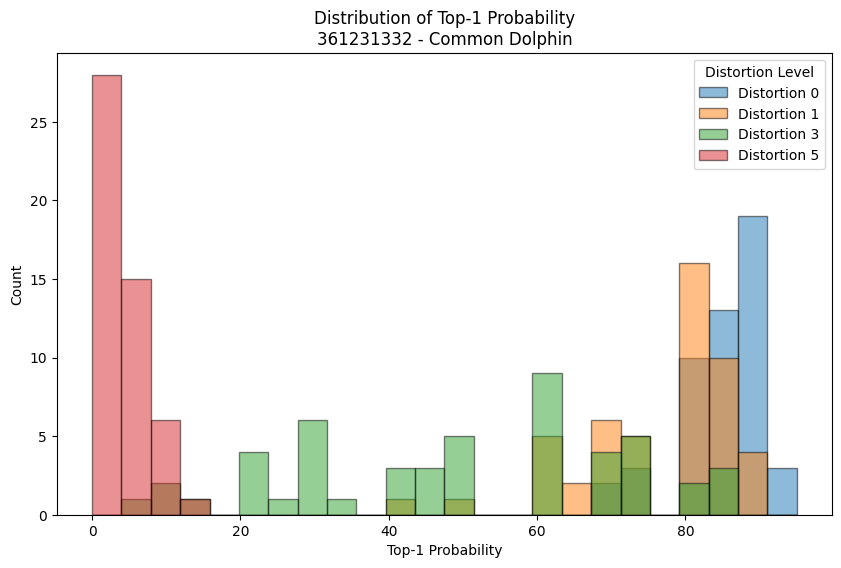

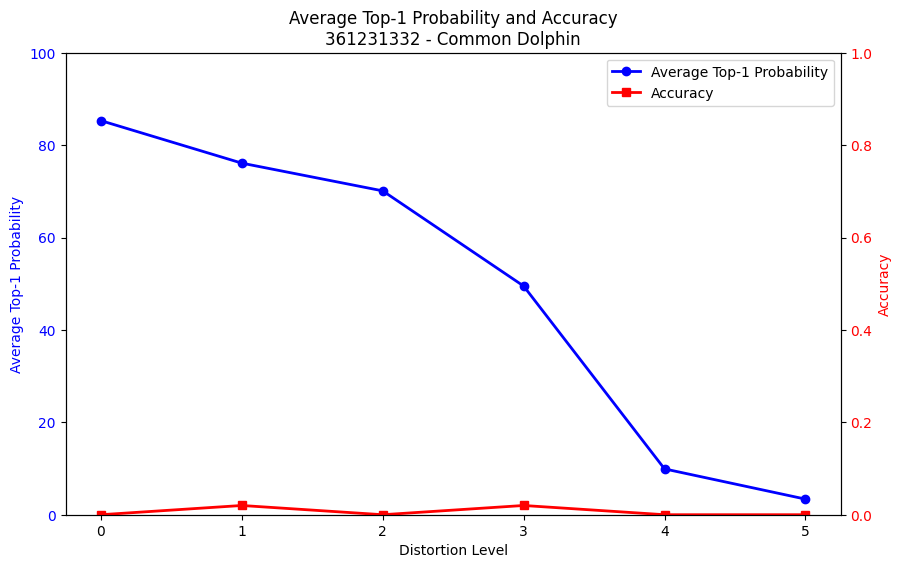

Saved:
  charts/361231332_histogram.png
  charts/361231332_dual_axis.png




362234822


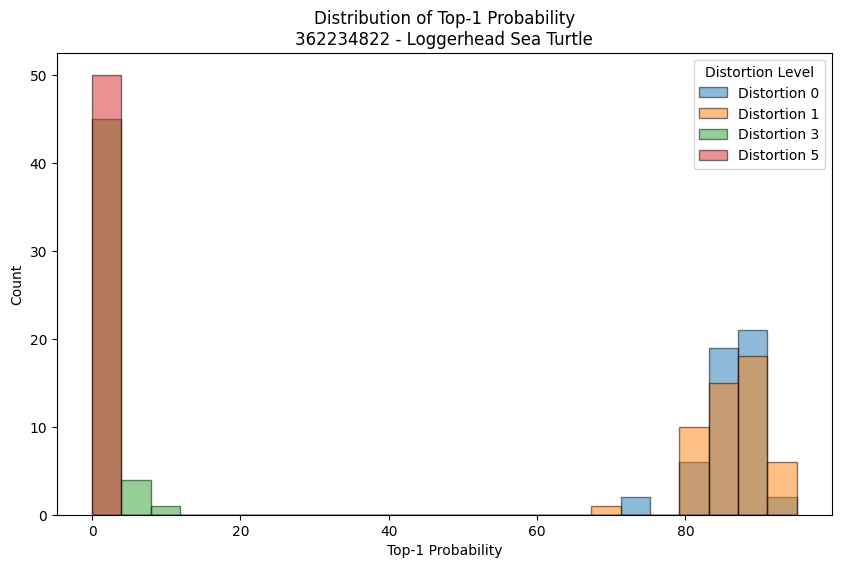

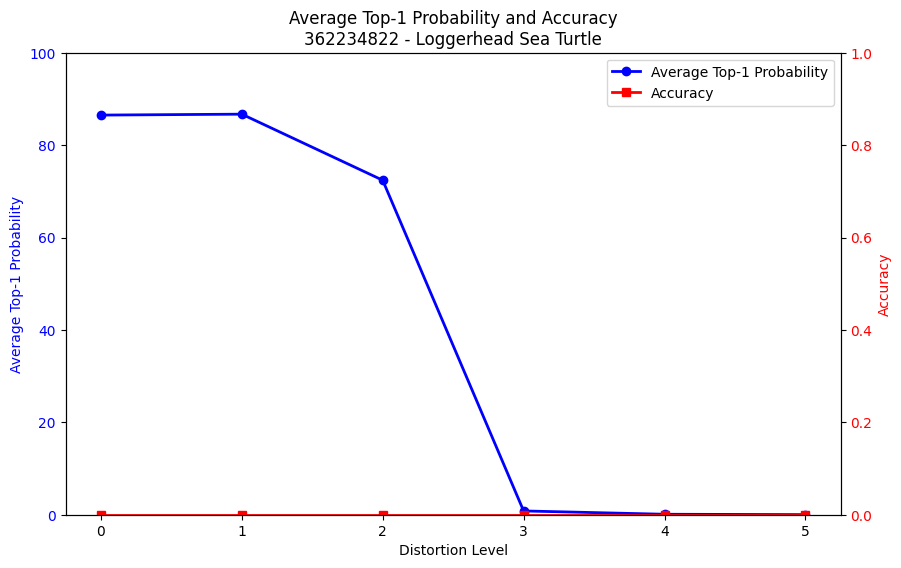

Saved:
  charts/362234822_histogram.png
  charts/362234822_dual_axis.png




362471929


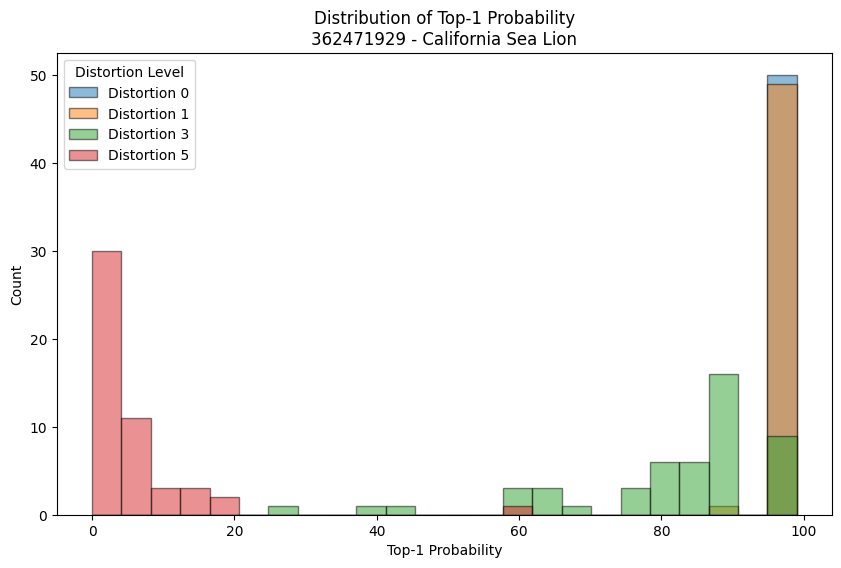

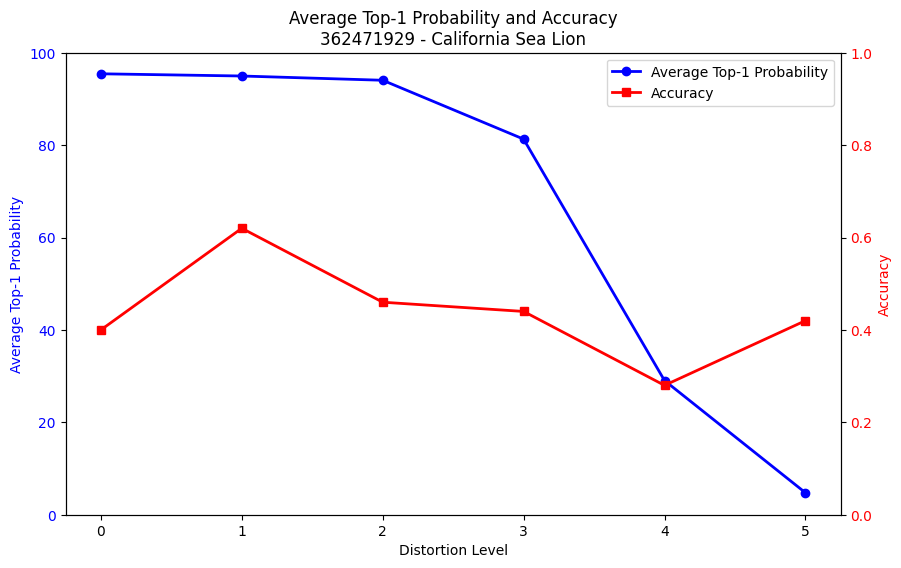

Saved:
  charts/362471929_histogram.png
  charts/362471929_dual_axis.png




362424973


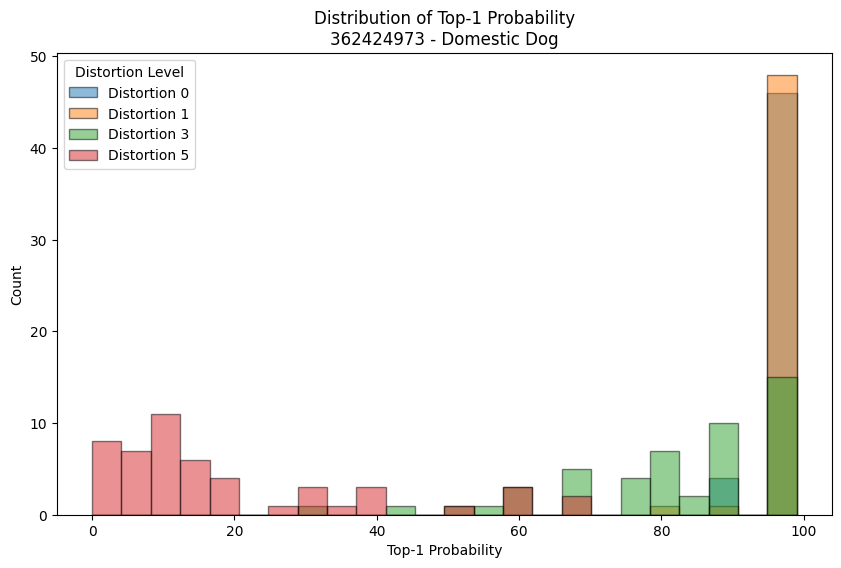

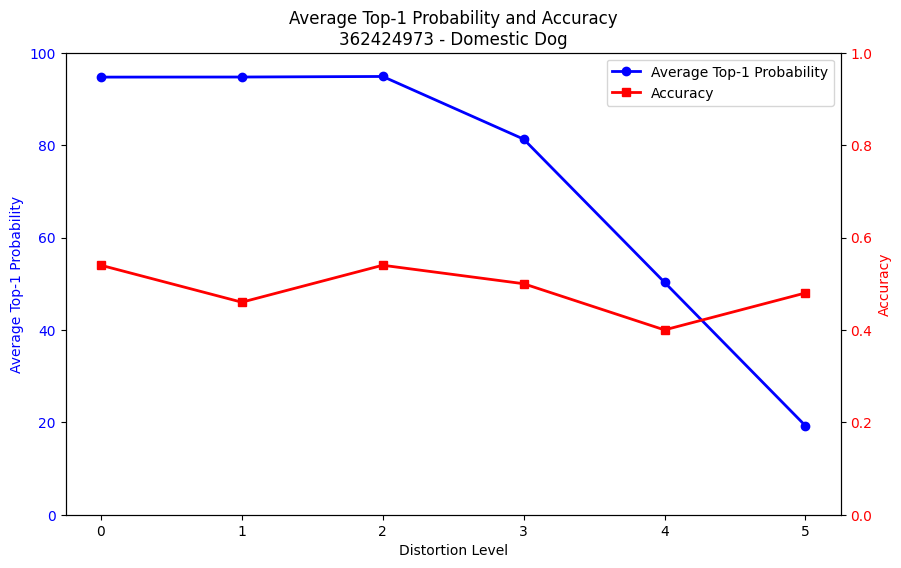

Saved:
  charts/362424973_histogram.png
  charts/362424973_dual_axis.png




362588731


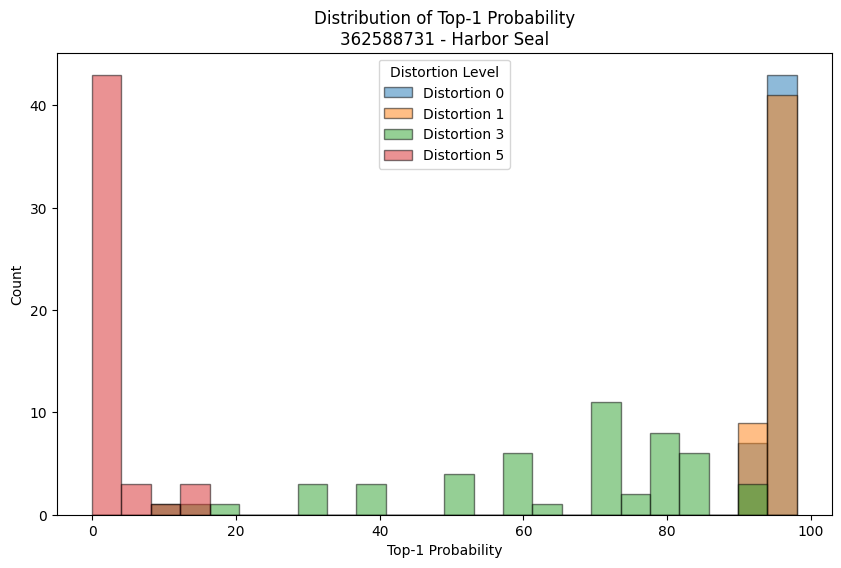

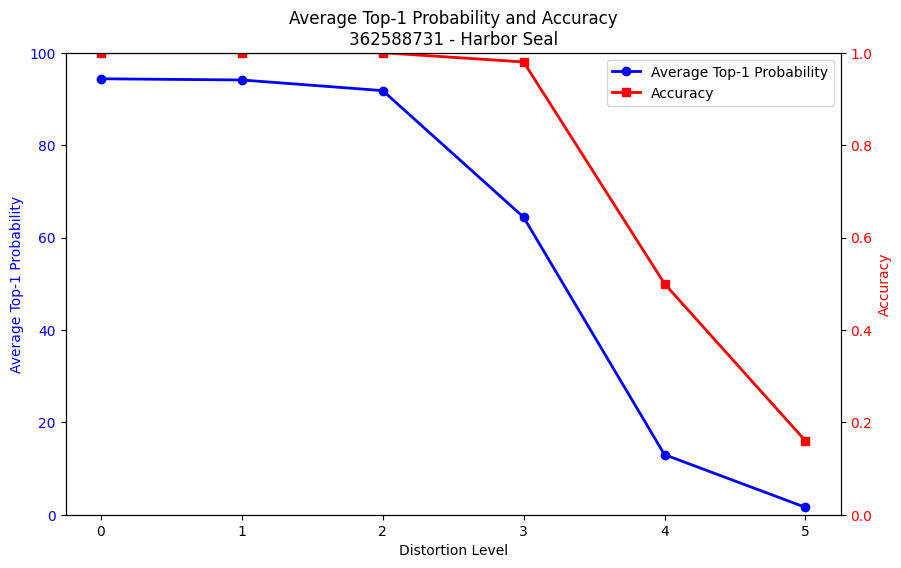

Saved:
  charts/362588731_histogram.png
  charts/362588731_dual_axis.png






In [11]:
TARGET_IDS = [361231332, 362234822, 362471929, 362424973, 362588731]

for i in TARGET_IDS:
    print(i)
    create_charts(f'{i}_distribution_results.csv')
    print('\n')
    print('\n')

In [55]:
file_path = 'all_images_distortion_results.csv'

In [60]:
df = pd.read_csv(file_path)
df['top1_prob'] = pd.to_numeric(df['top1_prob'], errors='coerce')
# 2. Drop rows where top1_prob is now NaN
#df = df.dropna(subset=['top1_prob'])
df["accurate"] = (
    df["actual_name"].astype(str).str.lower().str.strip()
    ==
    df["top1_common_name"].astype(str).str.lower().str.strip()
)

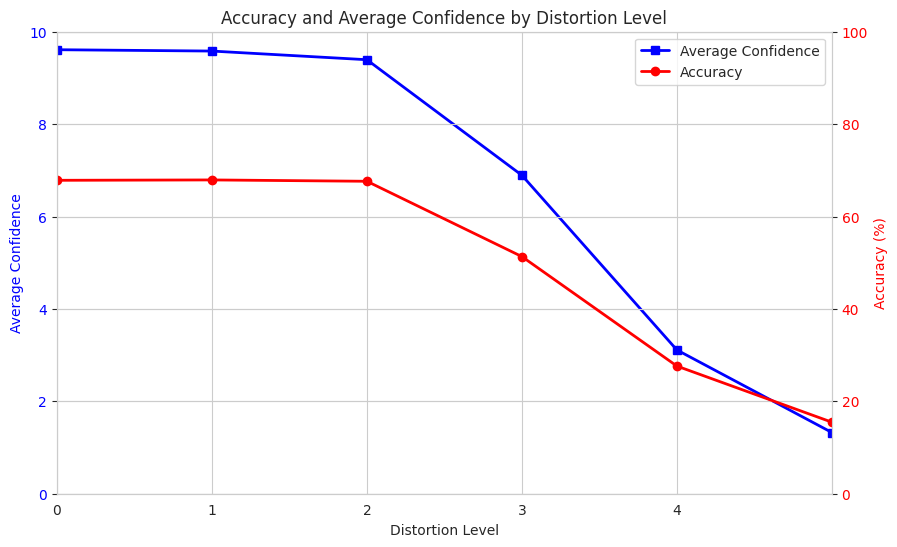

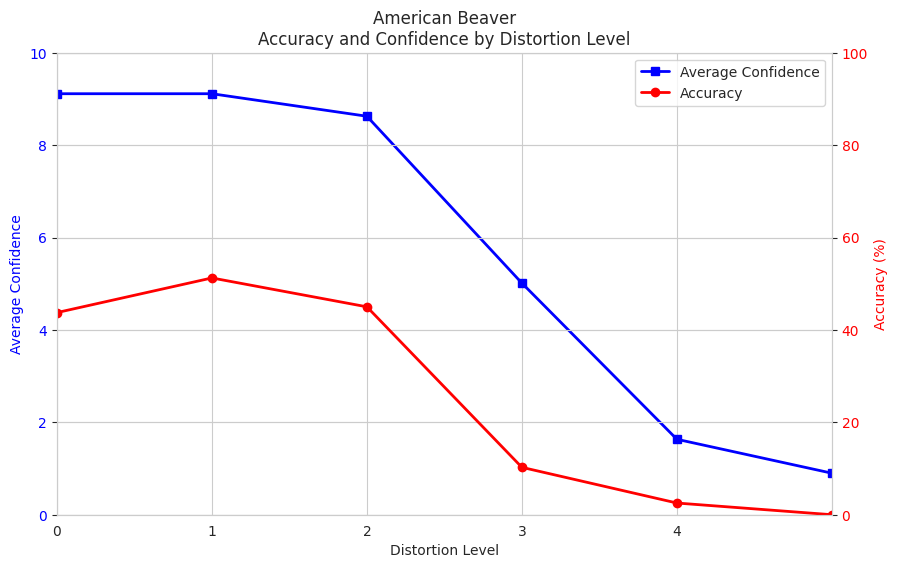

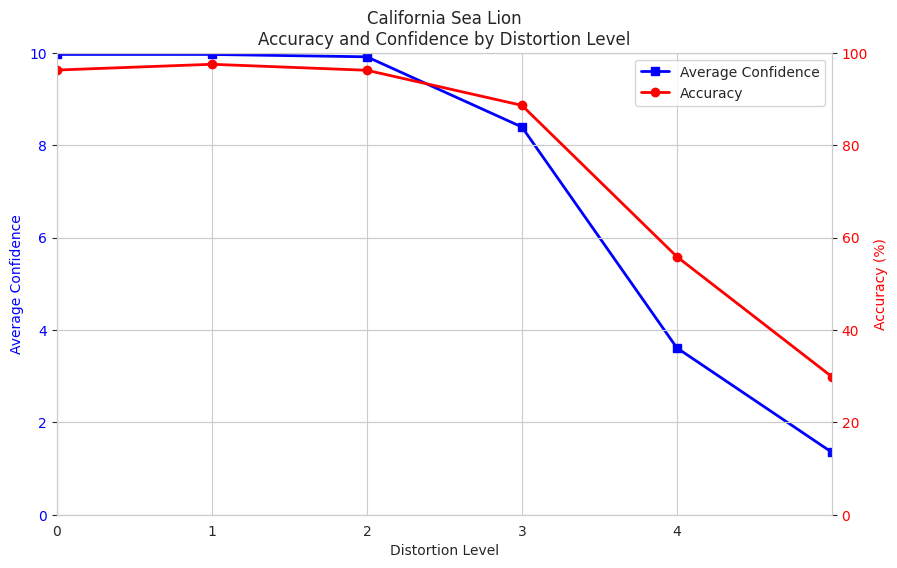

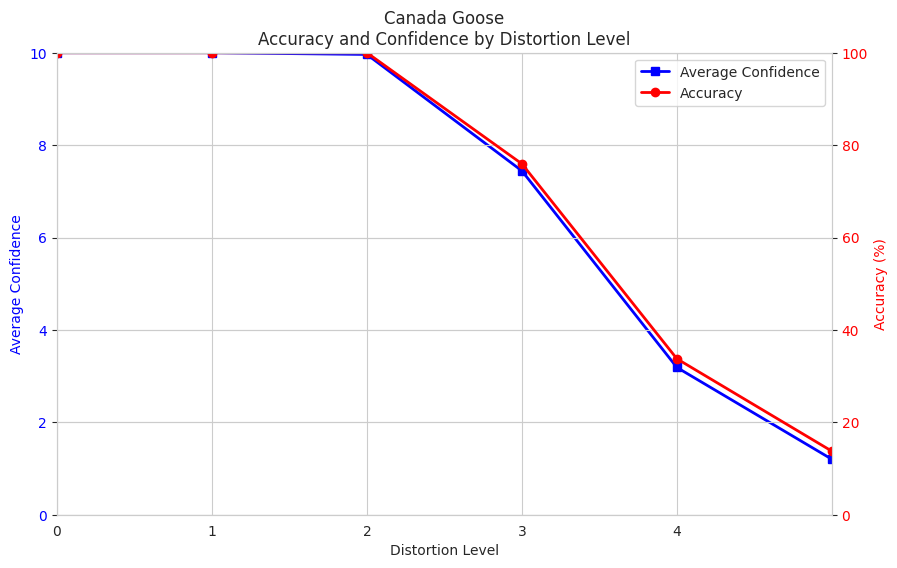

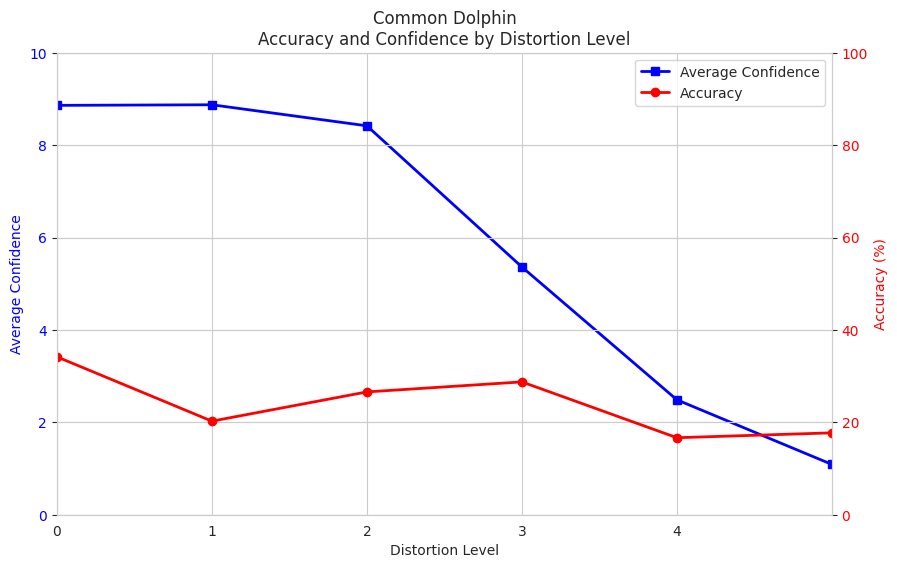

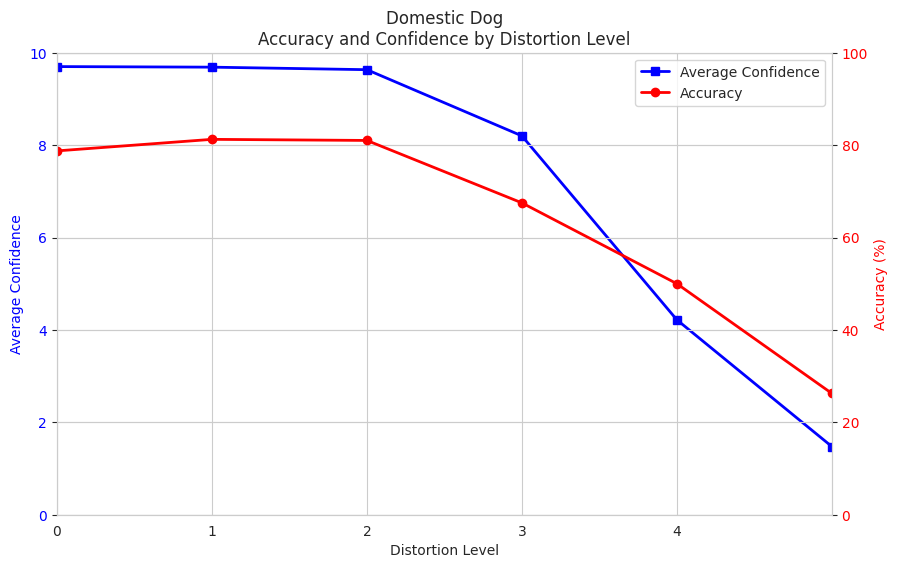

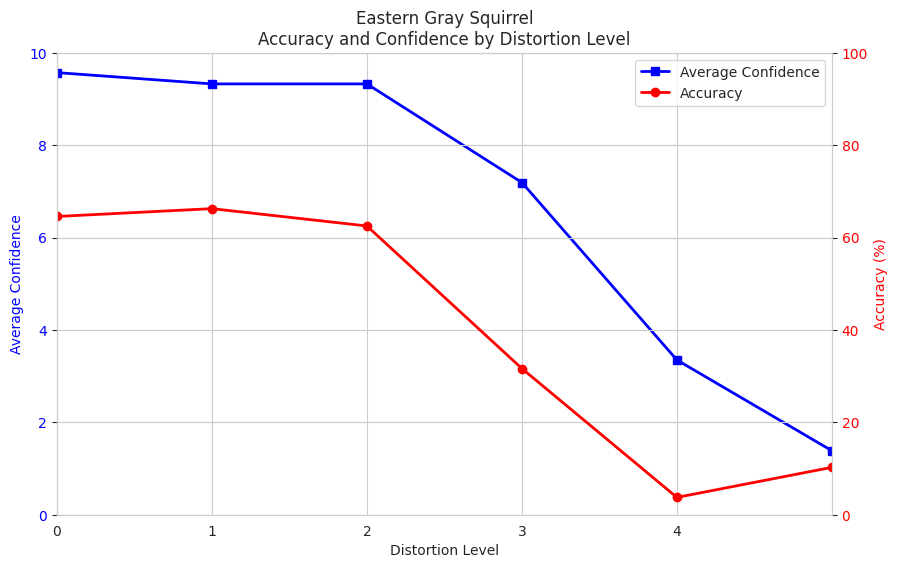

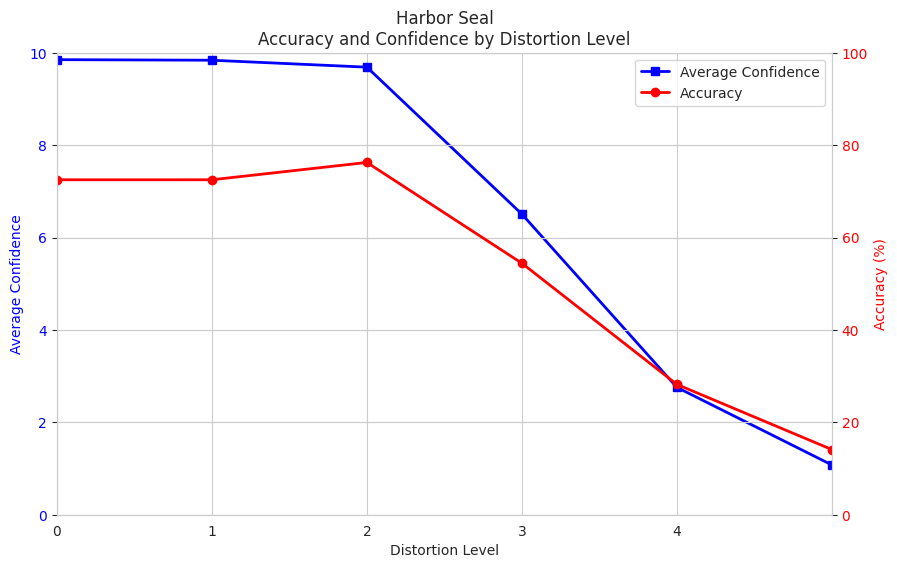

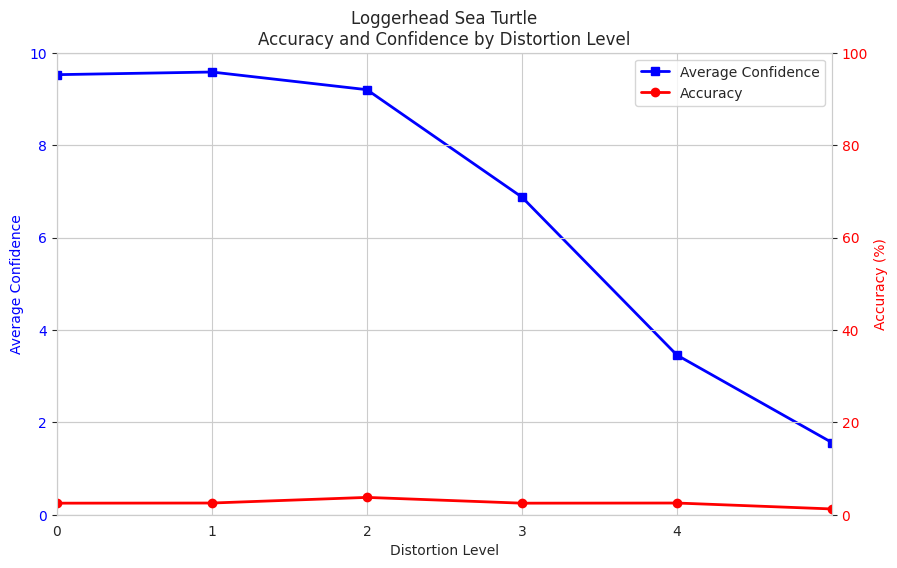

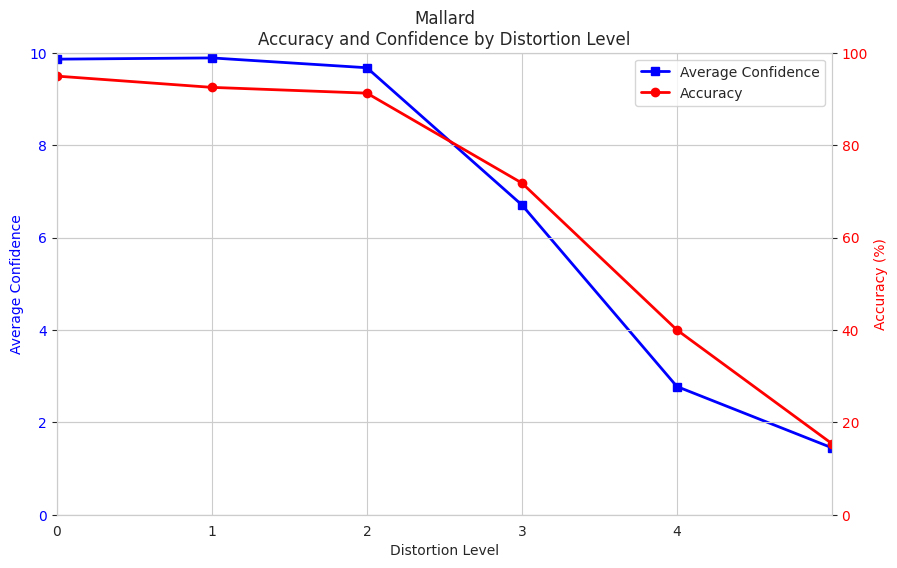

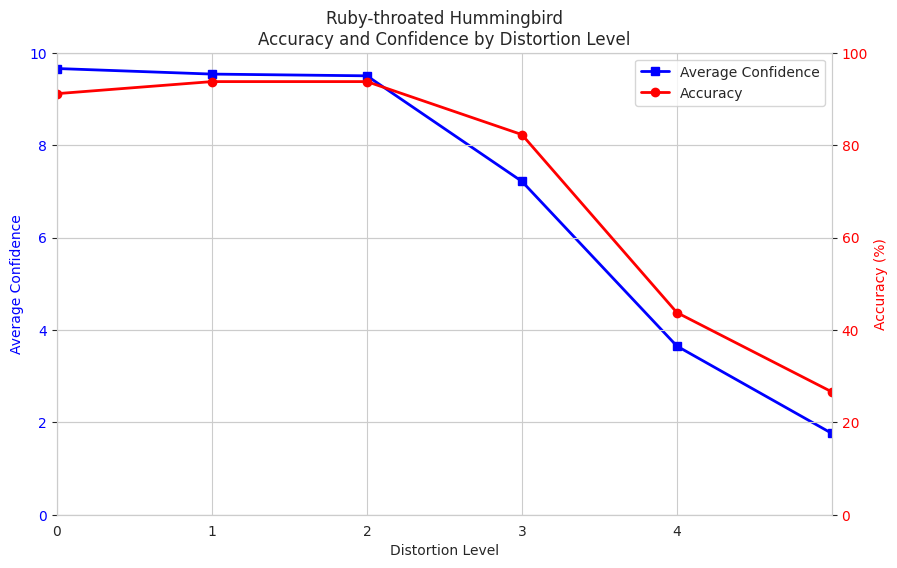

Done.


In [67]:
# Drop missing
df = df.dropna(subset=["distortion_level", "top1_prob"])

# Create output folder
OUTPUT_DIR = Path("charts_all_images")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")

# =====================================================
# 1. OVERALL LINE PLOT
# =====================================================

summary = (
    df.groupby("distortion_level")
    .agg(
        accuracy=("accurate", "mean"),
        avg_confidence=("top1_prob", "mean")
    )
    .reset_index()
    .sort_values("distortion_level")
)

fig, ax1 = plt.subplots(figsize=(10, 6))

# =====================================================
# LEFT AXIS = CONFIDENCE (BLUE)
# =====================================================

line1 = ax1.plot(
    summary["distortion_level"],
    summary["avg_confidence"],
    marker="s",
    linewidth=2,
    color="blue",
    label="Average Confidence"
)

ax1.set_xlabel("Distortion Level")
ax1.set_ylabel("Average Confidence", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax1.set_ylim(0, 10)
ax1.set_xlim(0, 5)
ax1.set_xticks(range(0, 5))

# =====================================================
# RIGHT AXIS = ACCURACY (RED)
# =====================================================

ax2 = ax1.twinx()

line2 = ax2.plot(
    summary["distortion_level"],
    summary["accuracy"] * 100,
    marker="o",
    linewidth=2,
    color="red",
    label="Accuracy"
)

ax2.set_ylabel("Accuracy (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax2.set_ylim(0, 100)

# =====================================================
# LEGEND
# =====================================================

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

ax1.legend(lines, labels, loc="best")

plt.title("Accuracy and Average Confidence by Distortion Level")

plt.savefig(
    OUTPUT_DIR / "overall_accuracy_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

# =====================================================
# 2. ONE CHART PER actual_name
# =====================================================

species_list = sorted(df["actual_name"].dropna().unique())

for species in species_list:

    species_df = df[df["actual_name"] == species]

    # Skip if empty
    if len(species_df) == 0:
        continue

    summary = (
        species_df.groupby("distortion_level")
        .agg(
            accuracy=("accurate", "mean"),
            avg_confidence=("top1_prob", "mean")
        )
        .reset_index()
        .sort_values("distortion_level")
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # =====================================================
    # LEFT AXIS = CONFIDENCE (BLUE)
    # =====================================================
    
    line1 = ax1.plot(
        summary["distortion_level"],
        summary["avg_confidence"],
        marker="s",
        linewidth=2,
        color="blue",
        label="Average Confidence"
    )
    
    ax1.set_xlabel("Distortion Level")
    ax1.set_ylabel("Average Confidence", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    ax1.set_ylim(0, 10)
    ax1.set_xlim(0, 5)
    ax1.set_xticks(range(0, 5))
    
    # =====================================================
    # RIGHT AXIS = ACCURACY (RED)
    # =====================================================
    
    ax2 = ax1.twinx()
    
    line2 = ax2.plot(
        summary["distortion_level"],
        summary["accuracy"] * 100,
        marker="o",
        linewidth=2,
        color="red",
        label="Accuracy"
    )
    
    ax2.set_ylabel("Accuracy (%)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    ax2.set_ylim(0, 100)
    
    # =====================================================
    # LEGEND
    # =====================================================
    
    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    plt.title(f"{species}\nAccuracy and Confidence by Distortion Level")

    # Safe filename
    safe_name = (
        species.replace(" ", "_")
        .replace("/", "_")
    )

    plt.savefig(
        OUTPUT_DIR / f"{safe_name}_accuracy_confidence.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

print("Done.")